In [2]:
import sys
import os

import numpy as np
from certifi import where
from fontTools.misc.cython import returns
from matplotlib import pyplot as plt
from sqlalchemy.dialects.mssql.information_schema import columns

sys.path.append(os.path.abspath(".."))

import importlib
import pandas as pd

import volpy_func_lib as vp
import load_clean_lib
import table_lib
import vol_strat_lib as vs
import volpy_func_ticker_lib as vtp

importlib.reload(vp)
importlib.reload(load_clean_lib)
importlib.reload(table_lib)
importlib.reload(vs)
importlib.reload(vtp)

os.makedirs("figures/Analysis/Period", exist_ok=True)

In [3]:
sum_df = vtp.concat_ticker_datasets(vp.All_tickers, df_name="sum1")

Skipped 2/237 tickers: ['RUT', 'INDU']


In [4]:
df = sum_df[sum_df["ticker"].isin(vp.Liquid_tickers)].copy()
name = "Liquid"

# table_lib.vol_period_analysis(df, "Liquid")

# Quantile

In [5]:
df = sum_df
df = df[df["ticker"] == "SPX"]

# 1) Compute the 30th and 70th percentiles of SW_0_30 using only SPX
spx_mask = df['ticker'] == 'SPX'
q30, q70 = df.loc[spx_mask, 'SW_0_30'].quantile([0.3, 0.7])

# 2) Build a small DataFrame of SPX’s SW_0_30 by date
spx_sw = (
    df[spx_mask]
    .loc[:, ['date', 'SW_0_30']]
    .drop_duplicates()
    .set_index('date')
)

# 3) Assign periods to SPX dates
spx_sw = spx_sw.sort_index()

start, end = spx_sw.index.min(), spx_sw.index.max()
third = (end - start) / 3
bins = [start, start + third, start + 2 * third, end]

# include_lowest=True so the very first date lands in bin 1
spx_sw['period'] = pd.cut(
    spx_sw.index.to_series(),
    bins=bins,
    labels=[1, 2, 3],
    include_lowest=True
).astype(int)

spx_sw = (
    spx_sw
    .reset_index()  # bring date back as column
    .merge(df[['date', 'RV']], on='date', how='left')
    .set_index('date')
)

In [6]:
# df = sum_df
# df = df[df["ticker"] == "SPX"]
#
# # 1) Compute the 30th and 70th percentiles of SW_0_30 using only SPX
# spx_mask = df['ticker'] == 'SPX'
# q30, q70 = df.loc[spx_mask, 'SW_0_30'].quantile([0.3, 0.7])
#
# # 2) Build a small DataFrame of SPX’s SW_0_30 by date
# spx_sw = (
#     df[spx_mask]
#     .loc[:, ['date', 'SW_0_30']]
#     .drop_duplicates()
#     .set_index('date')
# )
#
# # 3) Assign periods to SPX dates
# spx_sw['period'] = pd.cut(
#     spx_sw['SW_0_30'],
#     bins=[-np.inf, q30, q70, np.inf],
#     labels=[3, 2, 1]
# ).astype(int)
#
# spx_sw = (
#     spx_sw
#     .reset_index()  # bring date back as column
#     .merge(df[['date', 'RV']], on='date', how='left')
#     .set_index('date')
# )

In [ ]:
import matplotlib.pyplot as plt

# name map for periods
period_names = {1: "$S_1$ (1996-2005)", 2: "$S_2$ (2005-2014)", 3: "$S_3$ (2014-2023)"}
# colour map for periods
colours      = {1: 'red',      2: 'orange',      3: 'green'}

fig, ax = plt.subplots(figsize=(10, 5))

# plot the SW series
ax.plot(spx_sw.index, spx_sw['SW_0_30'], color='black', label='SPX SW', lw=0.5)

# fill under curve by period with named labels
for period, colour in colours.items():
    mask = spx_sw['period'] == period
    ax.fill_between(
        spx_sw.index,
        spx_sw['SW_0_30'],
        where=mask,
        color=colour,
        alpha=0.4,
        interpolate=True,
        edgecolor='none',
        linewidth=0,
        label=period_names[period],
    )

ax.set_ylabel('SW')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("figures/Analysis/Period/SW_time_period.pdf")
plt.show()

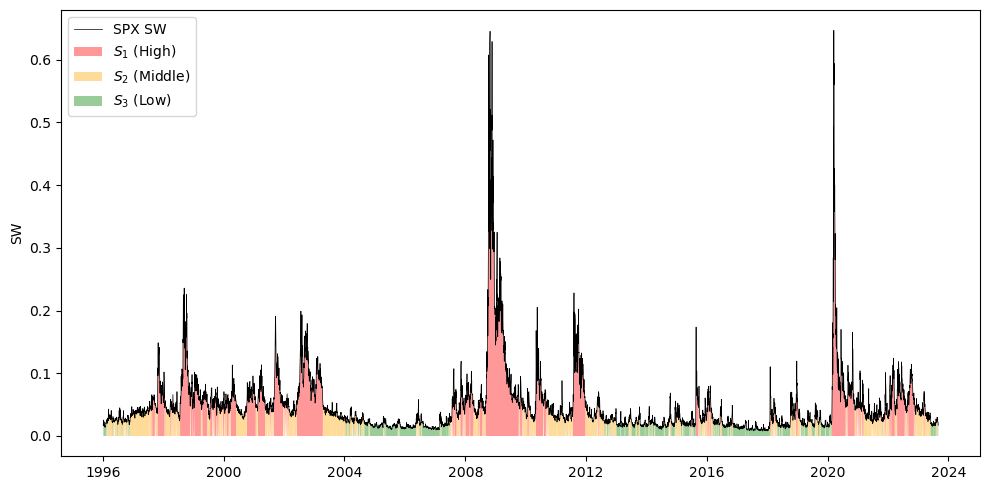

In [59]:
import matplotlib.pyplot as plt

# name map for periods
period_names = {1: r"$S_1$ (High)", 2: r"$S_2$ (Middle)", 3: r"$S_3$ (Low)"}
# colour map for periods
colours      = {1: 'red',      2: 'orange',      3: 'green'}

fig, ax = plt.subplots(figsize=(10, 5))

# plot the SW series
ax.plot(spx_sw.index, spx_sw['SW_0_30'], color='black', label='SPX SW', lw=0.5)

# fill under curve by period with named labels
for period, colour in colours.items():
    mask = spx_sw['period'] == period
    ax.fill_between(
        spx_sw.index,
        spx_sw['SW_0_30'],
        where=mask,
        color=colour,
        alpha=0.4,
        interpolate=True,
        edgecolor='none',
        linewidth=0,
        label=period_names[period],
    )

ax.set_ylabel('SW')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("figures/Analysis/Period/SW_quantile_period.pdf")
plt.show()

In [61]:
plt

<module 'matplotlib.pyplot' from 'C:\\ProgramData\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [8]:
import pandas as pd

def vol_period_analysis(sum_df, name):

    df = sum_df

    # 1) Compute the 30th and 70th percentiles of SW_0_30 using only SPX
    spx_mask = df['ticker'] == 'SPX'
    q30, q70 = df.loc[spx_mask, 'SW_0_30'].quantile([0.3, 0.7])
    
    # 2) Build a small DataFrame of SPX’s SW_0_30 by date
    spx_sw = (
        df[spx_mask]
        .loc[:, ['date', 'SW_0_30']]
        .drop_duplicates()
        .set_index('date')
    )
    
    # 3) Assign periods to SPX dates
    spx_sw['period'] = pd.cut(
        spx_sw['SW_0_30'],
        bins=[-np.inf, q30, q70, np.inf],
        labels=[3, 2, 1]
    ).astype(int)
    
    # 4) Merge that period label back onto the full df (matching on date)
    df = df.merge(
        spx_sw['period'].rename('period'),
        left_on='date',
        right_index=True,
        how='left'
    )

    # 1) start with all unique tickers
    tickers = df['ticker'].unique()
    period_df = pd.DataFrame({'ticker': tickers})
    
    # 2) loop over your three periods
    periods = [1, 2, 3]
    for p in periods:
        sub = df[df['period'] == p]
        
        # 2a) Carr & Wu Table 2 (Mean_RV, Mean_SW)
        tbl2 = table_lib.CarrWu2009_table_2(sub, "Liquid", save_latex=False)
        # if ticker is the index, bring it back as a column
        # if tbl2.index.name == 'ticker' or isinstance(tbl2.index, pd.Index):
        #     tbl2 = tbl2.reset_index().rename(columns={'index':'ticker'})
        tmp2 = tbl2[['ticker', 'Mean_RV', 'Mean_SW']].rename(columns={
            'Mean_RV': f'Mean_RV_{p}',
            'Mean_SW': f'Mean_SW_{p}',
        })
        period_df = period_df.merge(tmp2, on='ticker', how='left')
    
        # 2b) Carr & Wu Table 3 (VRP, t-stats, LVRP, t-stats)
        tbl3 = table_lib.CarrWu2009_table_3(sub, "Liquid", save_latex=False)
        # if tbl3.index.name == 'ticker' or isinstance(tbl3.index, pd.Index):
        #     tbl3 = tbl3.reset_index().rename(columns={'index':'ticker'})
        tmp3 = tbl3[['ticker', 'Mean_diff','t_diff','Mean_ln','t_ln']].rename(columns={
            'Mean_diff': f'VRP_{p}',
            't_diff':   f't_VRP_{p}',
            'Mean_ln':  f'LVRP_{p}',
            't_ln':     f't_LVRP_{p}',
        })
        period_df = period_df.merge(tmp3, on='ticker', how='left')
    
    # 3) (optional) sort tickers
    period_df = period_df.sort_values('ticker').reset_index(drop=True)
    period_df = table_lib.sort_table_df(period_df, df, name)
    period_df["ticker"] = vp.ticker_list_to_ordered_map(period_df["ticker"])["ticker_out"]
    
    vol_period_analysis_latex(period_df)
    
    return period_df



def vol_period_analysis_latex(out):
    # 1) Prepare a copy and format RV and SW to two‐decimal strings
    
    
    # 1) scale RV and SW by 100
    for p in [1, 2, 3]:
        out[f"RV_{p}"] = out[f"Mean_RV_{p}"]
        out[f"SW_{p}"] = out[f"Mean_SW_{p}"]
    
    # 2) format VRP and LVRP with their t‐stats in parentheses
    for p in [1, 2, 3]:
        out[f"VRP_{p}"] = out.apply(
            lambda r: f"{r[f'VRP_{p}']:.2f}\\,( {r[f't_VRP_{p}']:.2f} )",
            axis=1
        )
        out[f"LVRP_{p}"] = out.apply(
            lambda r: f"{r[f'LVRP_{p}']:.2f}\\,( {r[f't_LVRP_{p}']:.2f} )",
            axis=1
        )
    
    
    
    for p in [1, 2, 3]:
        out[f"RV_{p}"] = out[f"RV_{p}"].map(lambda x: f"{x:.2f}")
        out[f"SW_{p}"] = out[f"SW_{p}"].map(lambda x: f"{x:.2f}")
    
    # 2) Select columns in the desired order
    cols = (
        ['ticker'] +
        [f"RV_{p}"   for p in [1,2,3]] +
        [f"SW_{p}"   for p in [1,2,3]] +
        [f"VRP_{p}"  for p in [1,2,3]] +
        [f"LVRP_{p}" for p in [1,2,3]]
    )
    out2 = out[cols]
    
    # 3) Build a MultiIndex for the two header rows
    first_row  = [''           ] \
               + ['RV\\times100']*3 \
               + ['SW\\times100']*3 \
               + ['(RV-SW)\\times100']*3 \
               + ['\\(\\ln(RV/SW)\\)']*3
    
    second_row = ['Ticker'] \
               + ['S1','S2','S3'] \
               + ['S1','S2','S3'] \
               + ['S1','S2','S3'] \
               + ['S1','S2','S3']
    
    out2.columns = pd.MultiIndex.from_arrays([first_row, second_row])
    
    # 4) Export to LaTeX with no index, allowing multicolumn headers, and tight columns
    body = out2.to_latex(
        index=False,
        escape=False,
        multicolumn=True,
        multicolumn_format='c',
        column_format='l' + '|rrr' * int((len(out2.columns)-1)/3)
    )
    
    lines = body.splitlines()
    
    # build the cmidrule line (adjust column numbers if you change column_format)
    cm = r"\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}"
    
    # find where the second header line ends (the one with all the multicolumn specs)
    # it's usually line 2 (0-based), but you can search for '\multicolumn' if you like
    lines.insert(3, cm)
    
    body = "\n".join(lines)
    
    
    # 5) Wrap in table+scalebox
    latex = f"""
    \\begin{{table}}[htbp]
      \\centering
      % reduce horizontal padding
      \\setlength{{\\tabcolsep}}{{3pt}}
      % scale to fit width
      \\scalebox{{0.7}}{{%
    {body}
      }}
      \\caption{{Period‐by‐period RV, SW, VRP, and LVRP (with t‐stats)}}
      \\label{{tab:period_metrics}}
    \\end{{table}}
    """
    
    with open(f"figures/Analysis/{name}_vol_period_analysis.tex", "w") as f:
        f.write(latex)


In [10]:
df = sum_df[sum_df["ticker"].isin(vp.Liquid_tickers)].copy()
name = "Liquid"

vol_period_analysis(df, "Liquid")

,ticker,Mean_RV_1,Mean_SW_1,VRP_1,t_VRP_1,LVRP_1,t_LVRP_1,Mean_RV_2,Mean_SW_2,VRP_2,...,VRP_3,t_VRP_3,LVRP_3,t_LVRP_3,RV_1,SW_1,RV_2,SW_2,RV_3,SW_3
0,SPX,7.754119,9.631856,"-1.88\,( -2.74 )",-2.743428,"-0.48\,( -10.27 )",-10.268409,2.569601,3.590422,"-1.02\,( -7.27 )",...,"-0.34\,( -1.91 )",-1.914585,"-0.57\,( -11.74 )",-11.742795,7.75,9.63,2.57,3.59,1.35,1.70
1,NDX,15.526849,16.728127,"-1.20\,( -1.31 )",-1.314894,"-0.30\,( -7.30 )",-7.302159,6.339049,7.427167,"-1.09\,( -4.34 )",...,"-0.45\,( -2.32 )",-2.323628,"-0.40\,( -9.68 )",-9.680837,15.53,16.73,6.34,7.43,2.36,2.82
2,OEX,7.704114,9.217326,"-1.51\,( -2.28 )",-2.281713,"-0.43\,( -9.28 )",-9.281855,2.694113,3.511777,"-0.82\,( -5.57 )",...,"-0.22\,( -1.22 )",-1.222389,"-0.50\,( -10.34 )",-10.343918,7.70,9.22,2.69,3.51,1.35,1.58
3,DJX,7.007156,9.139830,"-2.13\,( -3.05 )",-3.050354,"-0.55\,( -11.49 )",-11.487902,2.392579,3.423018,"-1.03\,( -6.96 )",...,"-0.36\,( -1.80 )",-1.801027,"-0.62\,( -12.23 )",-12.230373,7.01,9.14,2.39,3.42,1.33,1.69
4,SPY,9.293900,10.653306,"-1.36\,( -1.10 )",-1.102244,"-0.49\,( -7.34 )",-7.343659,2.566504,3.480829,"-0.91\,( -4.68 )",...,"-0.28\,( -1.45 )",-1.445731,"-0.56\,( -10.33 )",-10.334967,9.29,10.65,2.57,3.48,1.36,1.64
5,DIA,8.394899,9.852241,"-1.46\,( -1.27 )",-1.267275,"-0.52\,( -8.40 )",-8.395611,2.140311,3.141674,"-1.00\,( -6.54 )",...,"-0.32\,( -1.57 )",-1.570357,"-0.61\,( -11.88 )",-11.879595,8.39,9.85,2.14,3.14,1.31,1.62
6,QQQ,15.268605,17.740762,"-2.47\,( -2.67 )",-2.673463,"-0.39\,( -8.76 )",-8.758016,6.214712,7.713426,"-1.50\,( -5.26 )",...,"-0.62\,( -3.01 )",-3.006729,"-0.49\,( -11.04 )",-11.043704,15.27,17.74,6.21,7.71,2.20,2.81
7,OEF,6.941530,9.735416,"-2.79\,( -2.69 )",-2.687034,"-0.55\,( -9.09 )",-9.088213,2.493350,3.302458,"-0.81\,( -3.87 )",...,"-0.01\,( -0.02 )",-0.022215,"-0.50\,( -7.09 )",-7.089000,6.94,9.74,2.49,3.30,1.56,1.57
8,GOOG,13.924857,15.155813,"-1.23\,( -0.98 )",-0.975096,"-0.24\,( -3.73 )",-3.729980,7.713588,8.558814,"-0.85\,( -1.60 )",...,"-0.04\,( -0.06 )",-0.060981,"-0.28\,( -3.86 )",-3.863253,13.92,15.16,7.71,8.56,5.01,5.04
9,BKNG,38.313619,42.059073,"-3.75\,( -1.63 )",-1.634725,"-0.25\,( -4.95 )",-4.945561,29.209382,25.393166,"3.82\,( 0.98 )",...,"-1.47\,( -2.38 )",-2.378841,"-0.36\,( -7.42 )",-7.421182,38.31,42.06,29.21,25.39,8.87,10.34
